# Potato Disease Project

## Data Exploration

In [1]:
from glob import glob

file_paths = {
    "Healthy" : glob("./data/PlantVillage/Potato___healthy/*"),
    "Early-Blight" : glob("./data/PlantVillage/Potato___Early_blight/*"),
    "Late-Blight" : glob("./data/PlantVillage/Potato___Late_blight/*")
}

CLASS_TO_ID = {
    "Healthy": 0,
    "Early-Blight": 1,
    "Late-Blight": 2
}

ID_TO_CLASS = {
    0: "Healthy",
    1: "Early Blight Potato",
    2: "Late Blight Potato"
}


In [2]:
FILES_PATH = file_paths["Healthy"]
# Checking if all file have the same format
for file_path in FILES_PATH:
    file_extension = (file_path.split("."))[-1]

    if file_extension.lower() != "jpg":
        print(file_extension)

In [3]:
print(f"Number of Healthy Potatoes: {len(file_paths["Healthy"])}")
print(f"Number of Potatoes with Early Blight: {len(file_paths["Early-Blight"])}")
print(f"Number of Potatoes with Late Blight: {len(file_paths["Late-Blight"])}")

Number of Healthy Potatoes: 152
Number of Potatoes with Early Blight: 1000
Number of Potatoes with Late Blight: 1000


As we can see, there is clear class imbalance. We must also try checking the diversity of the data.

Let us start by viewing some of the images.

In [4]:
from IPython.display import HTML, display
import random

# Replace with your actual file paths
IMAGE_PATHS = list()

for paths in file_paths.values():
    IMAGE_PATHS += paths

random.shuffle(IMAGE_PATHS)
NUMBER_OF_IMAGES = 45

# Build HTML string with images side-by-side
html_content = "".join(
    f'<div style="display:inline-block; margin:10px;">'
    f'<img src="{path}" width="200"/>'
    f'</div>'
    for path in IMAGE_PATHS[:NUMBER_OF_IMAGES]
)

display(HTML(html_content))


I can see that most of the leaves are held upright. Moreover, there is clear class imbalance.

Maybe it will be good to apply some image augmentation on the training dataset...

In [5]:
import cv2
import random
from typing import List, Tuple
import numpy as np

def rotation_and_scaling(img:cv2.typing.MatLike) -> cv2.typing.MatLike:
    """
    Apply random rotation and scaling to img
    """
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    center = (img_rgb.shape[1] // 2, img_rgb.shape[0] // 2)
    angle = random.randint(-359,360)
    scale = random.randint(7,14) / 10.0

    # Rotation and scaling
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
    rotated_image = cv2.warpAffine(img_rgb, rotation_matrix, (img.shape[1], img.shape[0]))

    return rotated_image

# Not worth it
# def shearing(img:cv2.typing.MatLike, shx:float, shy:float) -> cv2.typing.MatLike:
#     shearing = np.array([[1,shx,0],[shy,1,0]], dtype=np.float32)
#     sheared_img = cv2.warpAffine(img, shearing, (300,200))

#     return sheared_img

def brightness_control(img: cv2.typing.MatLike)-> cv2.typing.MatLike:
    return cv2.convertScaleAbs(src=img, alpha=(random.randint(3,17) / 10), beta=1)

def augment_data(files: List[Tuple[cv2.typing.MatLike,int]], target_size: int) -> List[Tuple[cv2.typing.MatLike,int]]:

    num_loops = int(target_size // len(files)) + 1
    augmented_data = list()
    augmented_data.extend(files)
    label_id = files[0][-1]
    
    for _ in range(num_loops):
        for tup in files:
            if len(augmented_data) >= target_size:
                break
            img = tup[0]

            # Apply rotation and scaling
            rotated_image = rotation_and_scaling(img)

            # Brightness augmentation
            augmented_img = brightness_control(rotated_image)

            augmented_data.append((augmented_img, label_id))
        if len(augmented_data) >= target_size:
            break

    return augmented_data

In [6]:
import cv2
import matplotlib.pyplot as plt
import random

max_file_count = 0
SPLIT_RATIO = 0.8

# Get maximum number of files
for values in file_paths.values():
    if len(values) > max_file_count:
        max_file_count = len(values)

target_size = SPLIT_RATIO * max_file_count

# Obtain the train dataset for healthy potato
split_index = int(SPLIT_RATIO * len(file_paths["Healthy"]))
healthy_file_paths = (file_paths["Healthy"])
healthy_image_data = [(cv2.imread(img_path),CLASS_TO_ID["Healthy"]) for img_path in healthy_file_paths]

train_healthy_image_data = healthy_image_data[:split_index]

augmented_healthy_image_data = augment_data(train_healthy_image_data, target_size)


In [7]:
len(augmented_healthy_image_data)

800

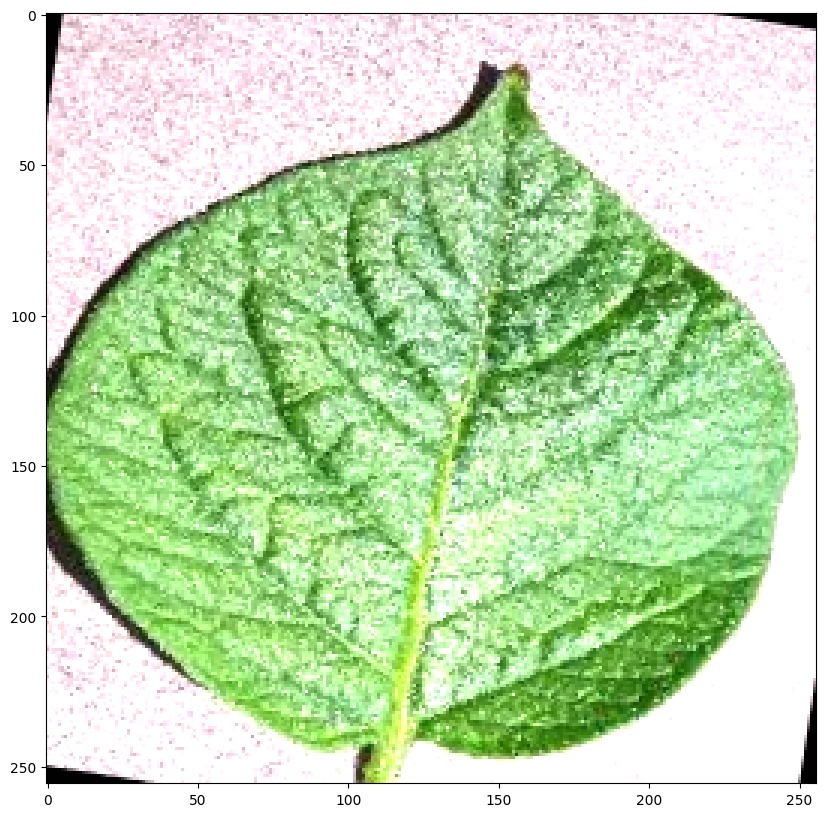

In [8]:
fig, axs = plt.subplots(1,1,figsize=(10,10))
axs.imshow(augmented_healthy_image_data[-10][0])

plt.show()

Now that we have performed data augmenatation, let us prepare our data into the train-test split.

In [9]:
early_blight_data = [(cv2.imread(img), CLASS_TO_ID["Early-Blight"]) for img in file_paths["Early-Blight"]]
late_blight_data = [(cv2.imread(img), CLASS_TO_ID["Late-Blight"]) for img in file_paths["Late-Blight"]]

In [10]:
print(late_blight_data[0][1])

2


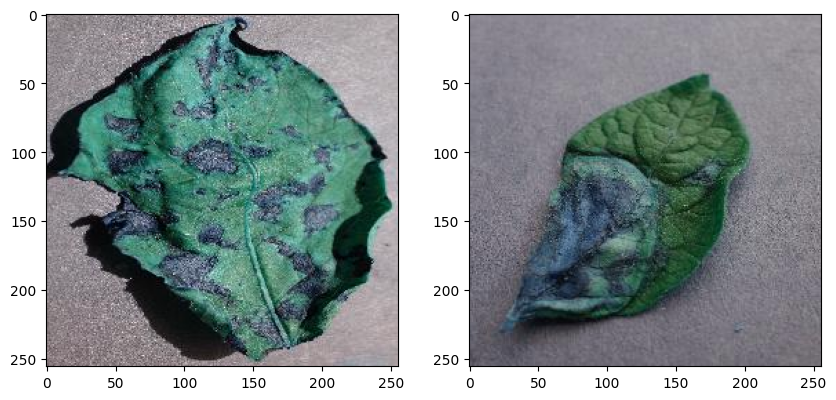

In [11]:
fig, axs = plt.subplots(1,2,figsize=(10,10))
axs[0].imshow(early_blight_data[0][0])
axs[1].imshow(late_blight_data[0][0])

plt.show()

Now we use the TF Data pipeline to prepare our datasets.

In [12]:
VAL_TEST_RATIO = 1
VAL_DATA_RATIO = round(((VAL_TEST_RATIO / (VAL_TEST_RATIO + 1)) * (1-SPLIT_RATIO)),1)
TRAIN_VAL_DATA_RATIO = VAL_DATA_RATIO + SPLIT_RATIO

target_size = int(target_size)

print("VAL_DATA_RATIO: ", VAL_DATA_RATIO)
print("TRAIN_VAL_DATA_RATIO: ", TRAIN_VAL_DATA_RATIO)

test_healthy_image_data_lower_index = int(TRAIN_VAL_DATA_RATIO * len(healthy_image_data))
test_early_blight_data_lower_index = int(TRAIN_VAL_DATA_RATIO * len(early_blight_data))
test_late_blight_data_lower_index = int(TRAIN_VAL_DATA_RATIO * len(late_blight_data))

print("test_healthy_image_data_lower_index: ", test_healthy_image_data_lower_index)
print("test_early_blight_data_lower_index: ", test_early_blight_data_lower_index)
print("test_late_blight_data_lower_index: ", test_late_blight_data_lower_index)

train_data = (augmented_healthy_image_data +
            early_blight_data[:target_size] +
            late_blight_data[:target_size])

val_data = (healthy_image_data[split_index: int(TRAIN_VAL_DATA_RATIO * len(healthy_image_data))] +
            early_blight_data[target_size: int(TRAIN_VAL_DATA_RATIO * len(early_blight_data))] +
            late_blight_data[target_size: int(TRAIN_VAL_DATA_RATIO * len(late_blight_data))])

test_data = (healthy_image_data[test_healthy_image_data_lower_index:] +
            early_blight_data[test_early_blight_data_lower_index:] +
            late_blight_data[test_late_blight_data_lower_index:])

print("train data: ", len(train_data))
print("val data: ", len(val_data))
print("test_data: ", len(test_data))


VAL_DATA_RATIO:  0.1
TRAIN_VAL_DATA_RATIO:  0.9
test_healthy_image_data_lower_index:  136
test_early_blight_data_lower_index:  900
test_late_blight_data_lower_index:  900
train data:  2400
val data:  215
test_data:  216


In [13]:
train_data_images = [img for img, _ in train_data]
train_data_labels = [label for _, label in train_data]

val_data_images = [img for img, _ in val_data]
val_data_labels = [label for _, label in val_data]

test_data_images = [img for img, _ in test_data]
test_data_labels = [label for _, label in test_data]

In [14]:
import tensorflow as tf

train_ds = tf.data.Dataset.from_tensor_slices((train_data_images, train_data_labels)).shuffle(buffer_size = len(train_data), seed= 42)
val_ds = tf.data.Dataset.from_tensor_slices((val_data_images, val_data_labels)).shuffle(buffer_size = len(val_data), seed = 42)
test_ds = tf.data.Dataset.from_tensor_slices((test_data_images, test_data_labels)).shuffle(buffer_size = len(test_data), seed= 42)

In [15]:
train_ds.batch(batch_size=32).prefetch(tf.data.AUTOTUNE)
val_ds.batch(batch_size=32).prefetch(tf.data.AUTOTUNE)
test_ds.batch(batch_size=32).prefetch(tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>